# Análisis de Rentabilidad por Canal de Adquisición - Showz

**Preguna de negocio:** ¿Qué canales de adquisición justifican su costo y hacia dónde debe reasignarse el presupuesto de marketing?

**contexto**: Showz es una plataforma de ventas de boletos paa eventos. El equipo de marketing invierte en multiples fuentes de anuncios sin saber cuáles devuelven más de lo que cuestan.

**Enfoque**: cálculo de CAC, LTV y ROMI por fuente, con análisis de cohortes mensuales sobre registros de visitas, pedidos y gastos. 

## 1.  Preparación de datos 
### 1.1 Carga e inspección incial

-  Cargamos las librerías que utilizaremos a lo largo del proyecto. Esto incluye herramientas para manipulación de datos, visualización y estadística.

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

- importamos los archivos de datos del Dataset "visits" y estudiamos la información general.

In [76]:
visits = pd.read_csv('visits_log_us.csv')
visits.info()
visits.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


,Source Id,Uid
count,359400.000000,3.594000e+05
mean,3.750515,9.202557e+18
std,1.917116,5.298433e+18
min,1.000000,1.186350e+13
25%,3.000000,4.613407e+18
50%,4.000000,9.227413e+18
75%,5.000000,1.372824e+19
max,10.000000,1.844668e+19


In [77]:
print('Número de filas duplicadas:', visits.duplicated().sum())


Número de filas duplicadas: 0


- Imprimimos una muestra de los datos del Dataset "visits".

In [78]:
visits.head(10)

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168
5,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387
6,desktop,2018-01-30 12:09:00,1,2018-01-30 11:13:00,6661610529277171451
7,touch,2017-11-05 15:15:00,3,2017-11-05 15:14:00,11423865690854540312
8,desktop,2017-07-19 10:44:00,3,2017-07-19 10:41:00,2987360259350925644
9,desktop,2017-11-08 13:43:00,5,2017-11-08 13:42:00,1289240080042562063


- Creamos un grupo de datos aleatorios para observar su coherencia.

In [79]:
visits.sample(10)

,Device,End Ts,Source Id,Start Ts,Uid
252194,desktop,2018-01-04 12:30:00,4,2018-01-04 12:30:00,12088649769433975654
287010,desktop,2017-12-27 15:30:00,3,2017-12-27 15:26:00,660875184000350476
110763,desktop,2018-04-05 19:58:00,4,2018-04-05 19:57:00,17859043271399492854
215409,touch,2018-01-04 07:46:00,3,2018-01-04 07:44:00,8343684814508796756
231204,touch,2018-01-20 12:51:00,4,2018-01-20 12:50:00,15730719514672518304
268964,desktop,2017-11-23 15:24:00,5,2017-11-23 15:23:00,11678674433715040025
332705,desktop,2017-10-15 00:10:00,5,2017-10-15 00:09:00,2650885315927337964
208910,touch,2018-04-24 09:33:00,4,2018-04-24 09:30:00,11496570345735995295
353552,desktop,2018-01-31 08:22:00,3,2018-01-31 08:22:00,14838848793499254912
116116,desktop,2017-07-27 23:09:00,5,2017-07-27 22:30:00,1419342668470540461


- Importamos los archivos de datos del Dataset "orders" y estudiamos la información general.

In [80]:
orders = pd.read_csv('orders_log_us.csv')
orders.info()
orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


,Revenue,Uid
count,50415.000000,5.041500e+04
mean,4.999647,9.098161e+18
std,21.818359,5.285742e+18
min,0.000000,3.135781e+14
25%,1.220000,4.533567e+18
50%,2.500000,9.102274e+18
75%,4.890000,1.368290e+19
max,2633.280000,1.844617e+19


In [81]:
print('Número de filas duplicadas:', orders.duplicated().sum())

Número de filas duplicadas: 0


- Imprimimos una muestra de los datos del Dataset "orders".

In [82]:
orders.head(10)

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
5,2017-06-01 08:43:00,0.18,10402394430196413321
6,2017-06-01 08:54:00,1.83,12464626743129688638
7,2017-06-01 09:22:00,1.22,3644482766749211722
8,2017-06-01 09:22:00,3.30,17542070709969841479
9,2017-06-01 09:23:00,0.37,1074355127080856382


- Creamos un grupo de datos aleatorios para observar su coherencia.

In [83]:
orders

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624
50411,2018-05-31 23:50:00,5.80,11369640365507475976
50412,2018-05-31 23:54:00,0.30,1786462140797698849
50413,2018-05-31 23:56:00,3.67,3993697860786194247


In [84]:
orders.sample(10)

,Buy Ts,Revenue,Uid
22627,2017-12-07 19:09:00,2.94,7046737606684150807
50225,2018-05-31 16:24:00,8.80,1779175132714002386
41570,2018-03-24 19:59:00,2.44,5094813567611788451
20188,2017-11-25 22:08:00,0.73,4985075170098889627
32233,2018-02-01 11:00:00,8.86,2910719870586044768
15395,2017-10-30 22:46:00,3.05,2420936041341208525
4591,2017-07-29 11:51:00,4.22,345670729557782714
12236,2017-10-11 18:36:00,34.22,12593176124809752646
26113,2017-12-26 11:51:00,14.67,6579116125854921508
17842,2017-11-16 12:51:00,13.33,12272054525473459183


- importamos los archivos de datos del Dataset "cost" y estudiamos la información general.

In [85]:
costs = pd.read_csv('costs_us.csv')
costs.info()
costs.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


,source_id,costs
count,2542.000000,2542.000000
mean,4.857199,129.477427
std,3.181581,156.296628
min,1.000000,0.540000
25%,2.000000,21.945000
50%,4.000000,77.295000
75%,9.000000,170.065000
max,10.000000,1788.280000


In [86]:
print('Número de filas duplicadas:', costs.duplicated().sum())

Número de filas duplicadas: 0


- Imprimimos una muestra de los datos del Dataset "cost".

In [87]:
costs.head(10)

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
5,1,2017-06-06,40.39
6,1,2017-06-07,40.59
7,1,2017-06-08,56.63
8,1,2017-06-09,40.16
9,1,2017-06-10,43.24


- Creamos un grupo de datos aleatorios para observar su coherencia.

In [88]:
costs.sample(10)

,source_id,dt,costs
1991,9,2017-11-23,29.16
2257,10,2017-08-18,16.98
649,2,2018-03-14,112.42
1582,5,2017-10-09,201.99
1962,9,2017-10-25,21.30
381,2,2017-06-19,58.54
1723,5,2018-02-27,212.55
1178,4,2017-08-29,1.74
1155,4,2017-08-06,31.19
2001,9,2017-12-03,9.26


### Conclusiones 1.1
### ¿Qué contienen los tres datasets?

- El Dataset "visits" contiene registros del servidor con datos sobre las visitas al sitio web.

    Las columnas son:

    - Uid: identificador único del usuario.

    - Device: dispositivo del usuario.

    - Start Ts: fecha y hora de inicio de la sesión.

    - End Ts: fecha y hora de término de la sesión.

    - Source Id: identificador de la fuente de anuncios de la que proviene el usuario.

    - Todas las fechas de esta tabla están en formato AAAA-MM-DD.

    - No contiene filas duplicadas.


- El Dataset "orders" contiene datos sobre pedidos.

    Las columnas son:

    - Uid: identificador único del usuario que realiza un pedido.

    - Buy Ts: fecha y hora del pedido. Revenue: el ingreso de Showz por el pedido.

    - No contiene filas duplicadas.

- El Dataset "costs" contiene datos sobre gastos de marketing.

    Las columnas son:

    - source_id: identificador de la fuente de anuncios.

    - dt: fecha.

    - costs: gastos en esta fuente de anuncios en este día.

    - No contiene filas duplicadas.

### 1.2  Limpieza de datos: tipos, duplicados y nombres de columna

- Utilizamos el formato snake_case para estandarizar los nombres de las columnas, manteniendo consistencia y legibilidad en el código.

In [89]:
visits.columns = (
    visits.columns
    .str.strip()
    .str.lower()
    .str.replace(' ','_')
)
orders.columns = (
    orders.columns
    .str.strip()
    .str.lower()
    .str.replace(' ','_')
)
costs.columns = (
    costs.columns
    .str.strip()
    .str.lower()
    .str.replace(' ','_')
)


- Cambiamos el tipo de datos de "object" a "datetime" en las columnas de los datasets que nos brindan fechas. Esto es fundamental para poder realizar cálculos de diferencias de tiempo, extraer componentes ocmo mes o semana, y agrupar por periodos temporales.

In [90]:
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

-  Corroboramos que los cambios se aplicaron correctamente. Verificamos que las columnas de fecha ahora aparezcan como datetie.

In [91]:
visits.info()
visits.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [92]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [93]:
costs.info()
costs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


- Se corroboran los cambios, nombres de las columnas estandarizados a snake_case en los 3 datasets, fechas corregidas correctamente a datetime. Datos limpios y listos para análisis.


---

## 2. Métricas de producto

### 2.1 Tráfico: DAU, WAU, MAU, y comportamiento de sesion


- Extraemos componenetes de fecha de "start_ts" para poder agrupar las visitas por dia, semana y mes. Creamos columnas auxiliares: "session_date", "session_year", "session month", "session week".

In [94]:
visits['session_year'] = visits['start_ts'].dt.isocalendar().year
visits['session_month'] = visits['start_ts'].dt.month
visits['session_week'] = visits['start_ts'].dt.isocalendar().week
visits['session_date'] = visits['start_ts'].dt.date
visits.head()

,device,end_ts,source_id,start_ts,uid,session_year,session_month,session_week,session_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017,12,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018,2,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017,7,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018,5,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017,12,52,2017-12-27


- Calculamos los Daily Active Users (DAU). Weekly Active Users (WAU) Y Monthly Active Users (MAU) contando usuarios únicos por período con "nunique()" y obtenemos el promedio del periodo con "mean()".

In [95]:
dau_total = visits.groupby('session_date').agg({'uid': 'nunique'}).mean()
print('DAU Total:', int(dau_total))
wau_total = visits.groupby(['session_year','session_week']).agg({'uid': 'nunique' }).mean()
print('WAU Total:', int(wau_total))
mau_total = visits.groupby(['session_year', 'session_month']).agg({'uid': 'nunique'}).mean()
print('MAU Total:', int(mau_total))

DAU Total: 907
WAU Total: 5716
MAU Total: 23228


/var/folders/4r/_2_gyjpn18sb18dbg9jxs5ym0000gn/T/ipykernel_30317/1603698431.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('DAU Total:', int(dau_total))
/var/folders/4r/_2_gyjpn18sb18dbg9jxs5ym0000gn/T/ipykernel_30317/1603698431.py:4: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('WAU Total:', int(wau_total))
/var/folders/4r/_2_gyjpn18sb18dbg9jxs5ym0000gn/T/ipykernel_30317/1603698431.py:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('MAU Total:', int(mau_total))


- El promedio de usuarios únicos por día (DAU) es 907, por semana (WAU) 5,716 y por mes (MAU) 23,228.

### Sesiones por día

- Contamos el número total de sesiones por día usando ".size()" ya que un usuario puede tener más de una sesión. Graficamos la evolución para identificar tendencias y estacionalidad.

Promedio de sesiones por día: 987.3626373626373
Primera session_date: 2017-06-01
Última session_date: 2018-05-31


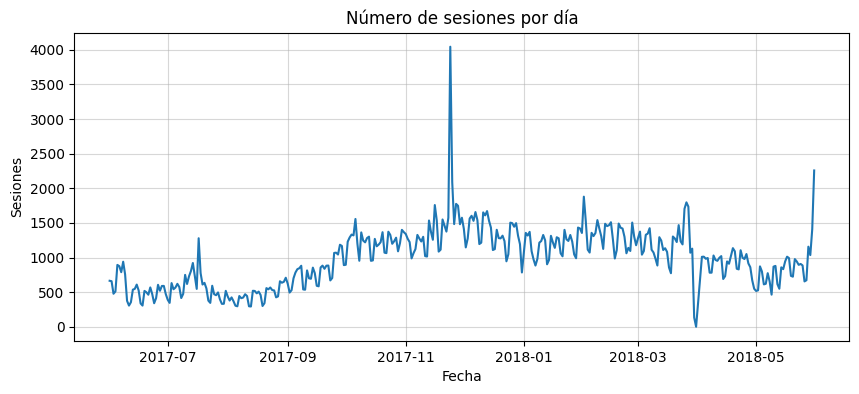

In [96]:
sessions_per_day = visits.groupby('session_date').size()
print('Promedio de sesiones por día:', sessions_per_day.mean())
first_date = visits['session_date'].min()
last_date  = visits['session_date'].max()
print("Primera session_date:", first_date)
print("Última session_date:", last_date)
plt.figure(figsize=(10,4))
sessions_per_day.plot()
plt.title('Número de sesiones por día')
plt.xlabel('Fecha')
plt.ylabel('Sesiones')
plt.grid(alpha=0.5)
plt.show()

- Se sacó un promedio de 987 sesiones por día. Es ligeramente mayor al DAU (907). Notamos que algunos usuarios abren más de una sesión por día.
- La gráfica muestra picos estacionales a lo largo del período analizado.

### Duración de sesión



- Calculamos la duración de cada sesión restando "start_ts" de "end_ts".

- Usamos ".dt.total_seconds()" para obtener el total completo. 

In [97]:
visits['session_duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()
print('Duración en segundos de cada sesión:')
visits['session_duration_sec'].head(10)


Duración en segundos de cada sesión:


0    1080.0
1    1680.0
2       0.0
3    1440.0
4       0.0
5      60.0
6    3360.0
7      60.0
8     180.0
9      60.0
Name: session_duration_sec, dtype: float64

In [98]:
print(visits['session_duration_sec'].min())
print(visits['session_duration_sec'].max())

-2760.0
42660.0


- Al revisar los valores extremos encontramos sesiones con duración negativa, lo que indica 
  errores en el registro del servidor (`end_ts` < `start_ts`). Primero cuantificamos cuántos 
  registros tienen este problema y luego los eliminamos para no distorsionar el análisis.

In [99]:
visits[visits['session_duration_sec'] < 0]

,device,end_ts,source_id,start_ts,uid,session_year,session_month,session_week,session_date,session_duration_sec
4181,desktop,2018-03-25 03:18:00,3,2018-03-25 03:50:00,13092152539246794986,2018,3,12,2018-03-25,-1920.0
177972,desktop,2018-03-25 03:09:00,9,2018-03-25 03:55:00,4621202742905035453,2018,3,12,2018-03-25,-2760.0


In [100]:
print('Sesiones con duración negativa:', (visits['session_duration_sec'] < 0).sum())

visits = visits[visits['session_duration_sec'] >= 0 ]

print('Nuevo mínimo:', visits['session_duration_sec'].min())
print('Nuevo máximo:', visits['session_duration_sec'].max())


Sesiones con duración negativa: 2
Nuevo mínimo: 0.0
Nuevo máximo: 42660.0


- Sacamos el Average Session Lenght (ASL), Mediana y Moda, también la distribución.

ASL: 643.0422873805642
Mediana: 300.0
Moda: 0    60.0
Name: session_duration_sec, dtype: float64

Distribución


Text(0, 0.5, 'Número de sesiones')

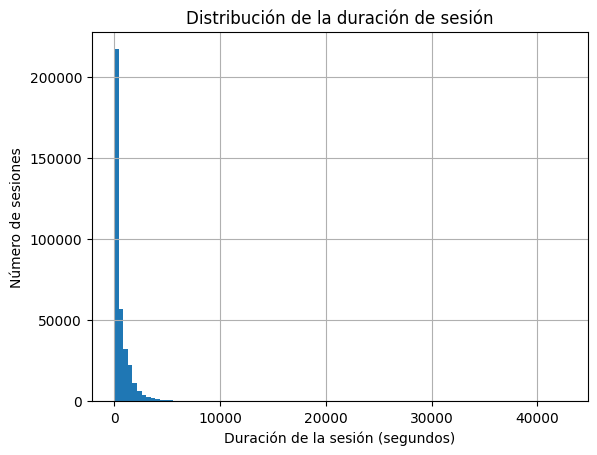

In [101]:
print('ASL:',visits['session_duration_sec'].mean())
print('Mediana:',visits['session_duration_sec'].median())
print('Moda:', visits['session_duration_sec'].mode())
print()
print('Distribución')
visits['session_duration_sec'].hist(bins=100)
plt.title('Distribución de la duración de sesión')
plt.xlabel('Duración de la sesión (segundos)')
plt.ylabel('Número de sesiones')


In [102]:
visits['session_duration_sec'].value_counts().head(10)

session_duration_sec
60.0     53029
0.0      35794
120.0    35748
180.0    26672
240.0    21085
300.0    17005
360.0    14316
420.0    12301
480.0    10973
540.0     9722
Name: count, dtype: int64

- Promedio (ASL): 643 segundos (10.7 min).
- Mediana: 300 segundos.
- Moda: 60 segundos.

- Distribución sesgada a la derecha: pocos usuarios con sesiones largas elevan el promedio.

### Factor de adherencia (Sticky factor)

- Calculamos el factor de adherencia (Sticky Factor) dividiendo DAU entre WAU y DAU entre MAU. Un valor alto indica que los usuarios regresan frecuentemente a la plataforma.

In [103]:
sticky_wau = dau_total / wau_total *100
sticky_mau = dau_total / mau_total *100
print('Factor de adherencia semanal:', sticky_wau)
print()
print('Factor de adherencia mensual:', sticky_mau)

Factor de adherencia semanal: uid    15.884409
dtype: float64

Factor de adherencia mensual: uid    3.90897
dtype: float64


- Factor de adherencia semanal = 15.9% / Mensual 3.9%.

### 2.2 Ventas: conversión, pedidos, ticket y LTV



- Obtenemos la primera visita y la primera compra de cada usuario para calcular cuántos días tardaron en convertirse. Si "conversion_d" = 0, el usuario compró el mismo día de su primera visita. 

In [104]:
first_visit = visits.groupby('uid', as_index=False)['start_ts'].min().rename(columns={'start_ts':'first_visit_ts'})
first_buy = orders.groupby('uid', as_index=False)['buy_ts'].min().rename(columns=({'buy_ts': 'first_buy_ts'}))
print(first_buy.head())
print(first_visit.head())


                uid        first_buy_ts
0   313578113262317 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 18:33:00
3  2464366381792757 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00
               uid      first_visit_ts
0   11863502262781 2018-03-01 17:27:00
1   49537067089222 2018-02-06 15:55:00
2  297729379853735 2017-06-07 18:47:00
3  313578113262317 2017-09-18 22:49:00
4  325320750514679 2017-09-30 14:29:00


In [105]:
conv = first_visit.merge(first_buy, on='uid')
conv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   uid             36523 non-null  uint64        
 1   first_visit_ts  36523 non-null  datetime64[ns]
 2   first_buy_ts    36523 non-null  datetime64[ns]
dtypes: datetime64[ns](2), uint64(1)
memory usage: 856.1 KB


In [106]:
conv['conversion_d'] = (conv['first_buy_ts'] - conv['first_visit_ts']).dt.days
conv.head()

,uid,first_visit_ts,first_buy_ts,conversion_d
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00,0
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00,0
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0


- Visualizamos la distribución de tiempos de conversión para los primeros 30 días y calculamos porcentajes acumulados de conversión.

conversion_d
0     26363
1      1011
2       563
3       434
4       324
5       270
6       260
7       218
8       189
9       140
10      140
11      100
12      112
13      125
14      122
Name: count, dtype: int64

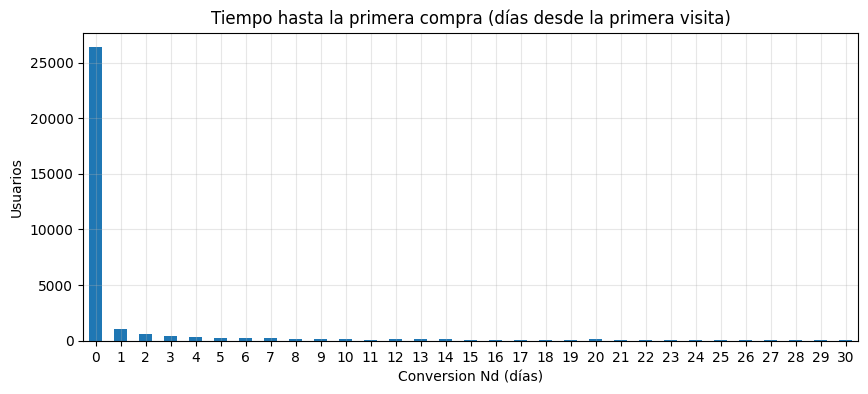

Conversión en día 0:  72.2%
Conversión en menos de 7 días:   80.6%
Conversión en menos de 30 días:  86.6%


In [107]:
conversion_dist = conv['conversion_d'].value_counts().sort_index()
display(conversion_dist.head(15))

plt.figure(figsize=(10,4))
conversion_dist.loc[:30].plot(kind='bar')
plt.title('Tiempo hasta la primera compra (días desde la primera visita)')
plt.xlabel('Conversion Nd (días)')
plt.ylabel('Usuarios')
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.show()

print(f"Conversión en día 0:  {(conv['conversion_d']==0).mean()*100:.1f}%")
print(f"Conversión en menos de 7 días:   {(conv['conversion_d']<=7).mean()*100:.1f}%")
print(f"Conversión en menos de 30 días:  {(conv['conversion_d']<=30).mean()*100:.1f}%")

- El 72.2% compra el mismo día de su primera visita.

- El 80.6% convierte en los primeros 7 días y el 86.6% en los primeros 30 días.

- Conclusión: los usuarios llegan con alta intención de compra.  Capturar al usuario en su primera visita es lo más efectivo.

- Creamos una tabla con el conversion rate en días.

In [108]:
conv['first_visit_month'] = conv['first_visit_ts'].dt.to_period('M')
conv['buy_month'] = conv['first_buy_ts'].dt.to_period('M')


In [109]:
conv.head()

,uid,first_visit_ts,first_buy_ts,conversion_d,first_visit_month,buy_month
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106,2017-09,2018-01
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0,2017-06,2017-06
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00,0,2017-10,2017-10
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00,0,2018-01,2018-01
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0,2017-11,2017-11


- Creamos una tabla pivot de conversión por cohorte mensual para ver cuántos usuarios de cada cohorte compraron en cada mes posterior a su primera visita. 

In [110]:
conv.pivot_table(
    index='first_visit_month',
    columns='buy_month',
    values='uid',
    aggfunc='nunique')

buy_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06
first_visit_month,,,,,,,,,,,,,
2017-06,2023.0,170.0,67.0,107.0,119.0,92.0,78.0,59.0,64.0,64.0,26.0,54.0,NaN
2017-07,NaN,1753.0,95.0,99.0,100.0,89.0,77.0,67.0,62.0,50.0,33.0,33.0,NaN
2017-08,NaN,NaN,1208.0,118.0,92.0,73.0,65.0,38.0,39.0,38.0,25.0,25.0,NaN
2017-09,NaN,NaN,NaN,2257.0,268.0,143.0,102.0,59.0,76.0,71.0,40.0,42.0,NaN
2017-10,NaN,NaN,NaN,NaN,3761.0,327.0,178.0,114.0,97.0,92.0,49.0,60.0,NaN
2017-11,NaN,NaN,NaN,NaN,NaN,3357.0,392.0,155.0,102.0,127.0,64.0,65.0,NaN
2017-12,NaN,NaN,NaN,NaN,NaN,NaN,3491.0,237.0,115.0,112.0,45.0,74.0,NaN
2018-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2644.0,244.0,114.0,50.0,67.0,NaN
2018-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2852.0,202.0,62.0,70.0,NaN


### Volumen de pedidos en el tiempo

- Agregamos columnas de tiempo al dataset de órdenes para agrupar los pedidos por día, semana y mes. Esto nos permitirpa analiar el volumen de ventas en diferentes granularidades e identificar patrones estacionales.

In [111]:
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
orders['order_week'] = orders['buy_ts'].dt.to_period('W').dt.start_time.dt.date
orders['order_day'] = orders['buy_ts'].dt.date
orders

,buy_ts,revenue,uid,order_month,order_week,order_day
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06,2017-05-29,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06,2017-05-29,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06,2017-05-29,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06,2017-05-29,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06,2017-05-29,2017-06-01
...,...,...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05,2018-05-28,2018-05-31
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05,2018-05-28,2018-05-31
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05,2018-05-28,2018-05-31
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05,2018-05-28,2018-05-31


- Visualizamos el número de pedidos por mes.

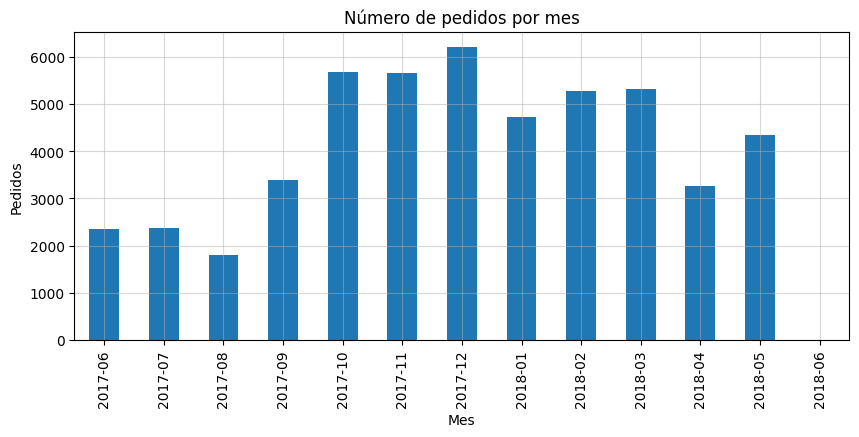

In [112]:
orders_x_month = orders.groupby('order_month')['uid'].count()
plt.figure(figsize=(10,4))
orders_x_month.plot(kind='bar')
plt.title('Número de pedidos por mes')
plt.xlabel('Mes')
plt.ylabel('Pedidos')
plt.grid(alpha=0.5)
plt.show()

- Visualizamos el número de pedidos por semana.

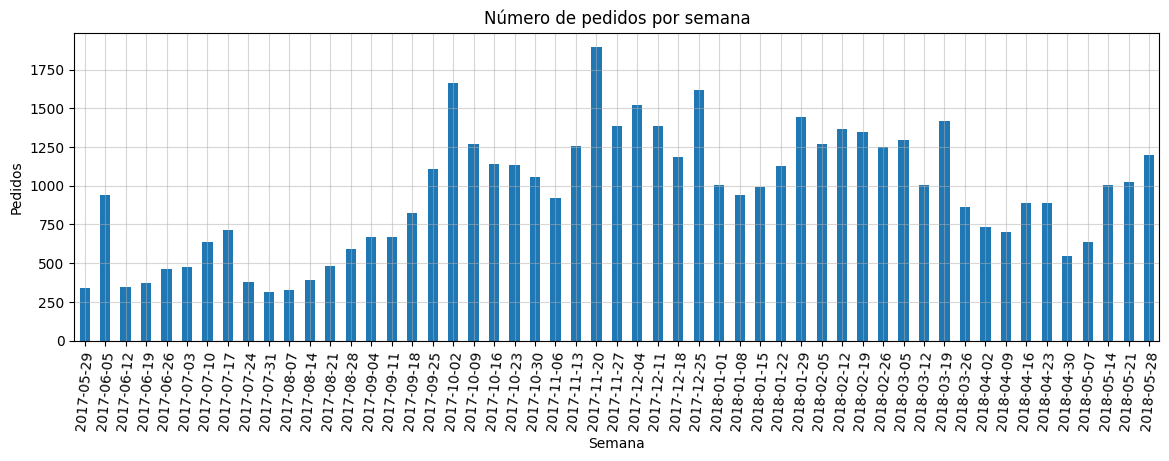

In [113]:
orders_x_week = orders.groupby('order_week')['uid'].count()
plt.figure(figsize=(14,4))
orders_x_week.plot(kind='bar',
                   rot=85)
plt.title('Número de pedidos por semana')
plt.xlabel('Semana')
plt.ylabel('Pedidos')
plt.grid(alpha=0.5)
plt.show()

- Visualizamos el número de pedidos por día.

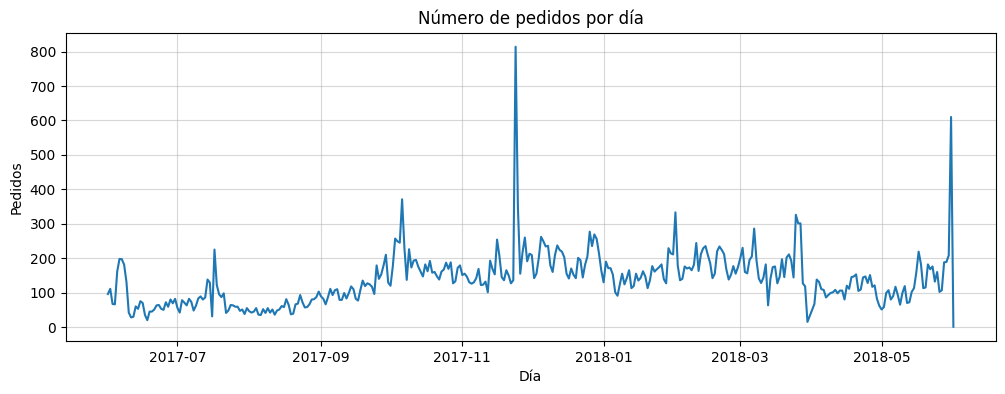

In [114]:
orders_x_day = orders.groupby('order_day')['uid'].count()
plt.figure(figsize=(12,4))
orders_x_day.plot()
plt.title('Número de pedidos por día')
plt.xlabel('Día')
plt.ylabel('Pedidos')
plt.grid(alpha=0.5)
plt.show()


In [115]:
print('Promedio de órdenes por mes:', orders_x_month.mean())
print('Promedio de órdenes por semana:', orders_x_week.mean())
print('Promedio de órdenes por día:', orders_x_day.mean())

Promedio de órdenes por mes: 3878.076923076923
Promedio de órdenes por semana: 951.2264150943396
Promedio de órdenes por día: 138.50274725274724


- Promedio de pedidos: 3,878 por mes, 951 por semana, 138 por día

- Observamos en las gráficas una estacionalidad clara: picos en fin de año y en verano.

### Ticket promedio

- Calculamos el revenue promedio por pedido (ticket promedio). Verificamos si existen pedidos con revenue igual a 0 o negativo que puedan distorsionar el cálculo. Visualizamos la distribución del revenue.

In [116]:
mean_revenue = orders['revenue'].mean()
print('Tamaño promedio de compra sin quitar valores en 0:', mean_revenue)

Tamaño promedio de compra sin quitar valores en 0: 4.999646930477041


In [117]:
print('Pedidos con revenue de 0 o negativo:', (orders['revenue'] <= 0).sum())

Pedidos con revenue de 0 o negativo: 51


In [118]:
mean_revenue_pos = orders.loc[orders['revenue'] > 0, 'revenue'].mean()
print('Tamaño promedio de compra quitando valores en 0:', mean_revenue_pos)

Tamaño promedio de compra quitando valores en 0: 5.004709713287269


Text(0.5, 0, 'Revenue (USD)')

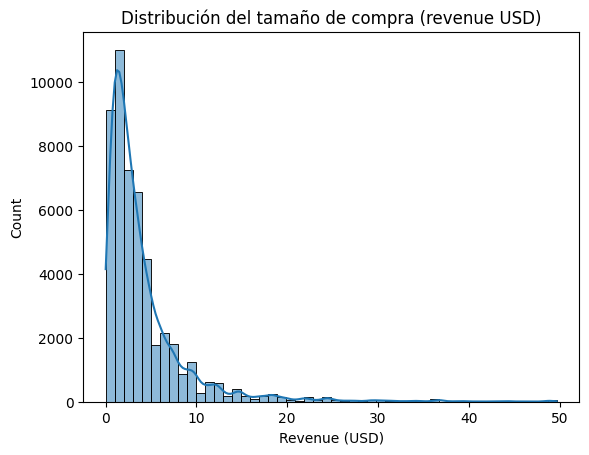

In [119]:
sns.histplot(orders.loc[orders['revenue'] < 50, 'revenue'], bins=50, kde=True)
plt.title('Distribución del tamaño de compra (revenue USD)')
plt.xlabel('Revenue (USD)')

- Revenue promedio de $5,000 USD.

- Notamos que la mayoria de las transacciones osn pequeñas, muy pocas son grandes que elevan la media.

- Un ticket bajo implica que el volumen de clientes es fundamental para la rentabilidad.

### Ingreso por cohorte (LTV)

- Calculamos el Life Time Value (LTV) por cohortes segíun el mes de la primera compra. La columna "age" indica cuántos meses han pasado desde la primera comra de la cohorte.

Creamos la columna "month" en el dataset costs.

In [120]:
costs['month'] = costs['dt'].dt.to_period('M')
costs.head()

,source_id,dt,costs,month
0,1,2017-06-01,75.20,2017-06
1,1,2017-06-02,62.25,2017-06
2,1,2017-06-03,36.53,2017-06
3,1,2017-06-04,55.00,2017-06
4,1,2017-06-05,57.08,2017-06


- Creamos un dataset con la información de fechas de la primera compra de cada usuario.

In [121]:
first_orders = orders.groupby('uid').agg({'order_month': 'min'}).reset_index()
first_orders.columns = ['uid', 'first_order_month']
first_orders.head()


,uid,first_order_month
0,313578113262317,2018-01
1,1575281904278712,2017-06
2,2429014661409475,2017-10
3,2464366381792757,2018-01
4,2551852515556206,2017-11


- Creamos otro dataset con la fecha de la priemra compra y el numero de usuarios que compraron por primera vez dentro de ese mes. 

In [122]:
cohort_sizes = first_orders.groupby('first_order_month').agg({'uid' : 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']
cohort_sizes.head()

,first_order_month,n_buyers
0,2017-06,2023
1,2017-07,1923
2,2017-08,1370
3,2017-09,2581
4,2017-10,4340


- Unimos los datasets

In [123]:
orders_ = pd.merge(orders, first_orders, on='uid')
orders_.head()

,buy_ts,revenue,uid,order_month,order_week,order_day,first_order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06,2017-05-29,2017-06-01,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06,2017-05-29,2017-06-01,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06,2017-05-29,2017-06-01,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06,2017-05-29,2017-06-01,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06,2017-05-29,2017-06-01,2017-06


- Agrupamos el dataset por fecha del mes de primera compra, y su revenue sumado.

In [124]:
cohorts = orders_.groupby(['first_order_month', 'order_month']).agg({'revenue' : 'sum'}).reset_index()
cohorts

,first_order_month,order_month,revenue
0,2017-06,2017-06,9557.49
1,2017-06,2017-07,981.82
2,2017-06,2017-08,885.34
3,2017-06,2017-09,1931.30
4,2017-06,2017-10,2068.58
...,...,...,...
74,2018-03,2018-05,1114.87
75,2018-04,2018-04,10600.69
76,2018-04,2018-05,1209.92
77,2018-05,2018-05,13925.76


- Generamos el dataset que contendrá nuestro reporte.

In [125]:
report = pd.merge(cohort_sizes, cohorts, on='first_order_month')
report.head()

,first_order_month,n_buyers,order_month,revenue
0,2017-06,2023,2017-06,9557.49
1,2017-06,2023,2017-07,981.82
2,2017-06,2023,2017-08,885.34
3,2017-06,2023,2017-09,1931.30
4,2017-06,2023,2017-10,2068.58


- Agregamos columna "age"

In [126]:

report['age'] = (report['order_month'] - report['first_order_month']).apply(lambda x: x.n)
report['age'] = report['age'].round().astype('int')
report.head(10)

,first_order_month,n_buyers,order_month,revenue,age
0,2017-06,2023,2017-06,9557.49,0
1,2017-06,2023,2017-07,981.82,1
2,2017-06,2023,2017-08,885.34,2
3,2017-06,2023,2017-09,1931.30,3
4,2017-06,2023,2017-10,2068.58,4
5,2017-06,2023,2017-11,1487.92,5
6,2017-06,2023,2017-12,1922.74,6
7,2017-06,2023,2018-01,1176.56,7
8,2017-06,2023,2018-02,1119.15,8
9,2017-06,2023,2018-03,1225.51,9


- Agregamos columna de LTV y creamos tabla pivot con los valores de LTV.

In [127]:
report['ltv'] = report['revenue'] / report['n_buyers']
output = report.pivot_table(
    index='first_order_month',
    columns='age',
    values='ltv',
    aggfunc='mean')
output.fillna('')


age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,4.724414,0.485329,0.437637,0.954671,1.022531,0.735502,0.95044,0.581592,0.553213,0.605788,0.571261,0.256856
2017-07,6.010218,0.335211,0.623531,0.358976,0.176791,0.156048,0.120208,0.14182,0.161232,0.147145,0.155673,
2017-08,5.276518,0.471993,0.458482,0.391277,0.494051,0.28354,0.210664,0.405007,0.292212,0.187978,,
2017-09,5.644529,1.117586,0.52093,3.975792,0.400558,0.647067,0.701608,0.24315,0.184006,,,
2017-10,5.003733,0.535763,0.191394,0.157145,0.15156,0.120362,0.084816,0.11547,,,,
2017-11,5.154683,0.399233,0.199556,0.324952,0.148013,0.053879,0.114928,,,,,
2017-12,4.738191,0.260374,0.925097,1.065275,0.31293,0.338047,,,,,,
2018-01,4.135636,0.294758,0.304281,0.142778,0.062698,,,,,,,
2018-02,4.156987,0.278274,0.078515,0.074144,,,,,,,,


- Calculamos el LTV total acumulado por cohorte sumando todas las edades y lo graficamos.

In [128]:
ltv_total_by_cohort = output.fillna(0).sum(axis=1).reset_index()
ltv_total_by_cohort = ltv_total_by_cohort.rename(columns={0: 'total_ltv'})
ltv_total_by_cohort

,first_order_month,total_ltv
0,2017-06,11.879234
1,2017-07,8.386854
2,2017-08,8.471723
3,2017-09,13.435227
4,2017-10,6.360242
5,2017-11,6.395244
6,2017-12,7.639913
7,2018-01,4.940151
8,2018-02,4.587921
9,2018-03,5.455253


Text(0.5, 0, 'Més de la primer orden')

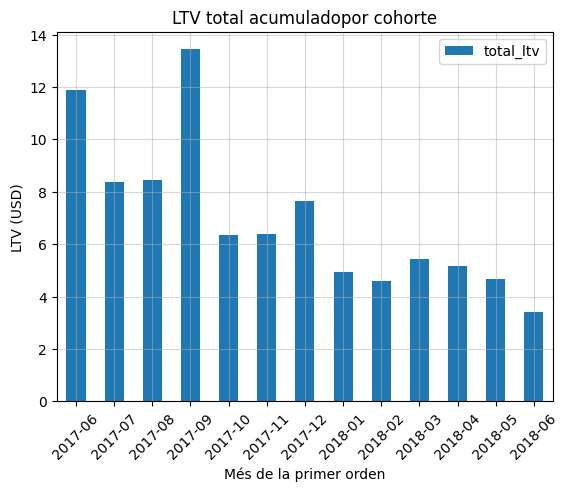

In [129]:
ltv_total_by_cohort.plot(kind='bar',
                         x='first_order_month',
                         rot=45,
                         y='total_ltv',
                         title= 'LTV total acumuladopor cohorte')
plt.grid(alpha=0.5)
plt.ylabel('LTV (USD)')
plt.xlabel('Més de la primer orden')


- Las cohortes mas antiguas muestran un mayor LTV acumulado debido a que han tenido más timepo para generar ingresos.

---

### 2.3 Marketing: CAC, LTV y ROMI por fuente


Costo por fuente de aquisición "source_id"

- Calculamos el gasto total agrupado por fuente de adquisición ("source_id") para identificar en cuáles canales se ha invertido más dinero.

In [130]:
costs_x_source = costs.groupby('source_id')['costs'].sum().reset_index()
costs_x_source

,source_id,costs
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10
5,9,5517.49
6,10,5822.49


- Visualizamos el Gasto total por fuente de adquisición.

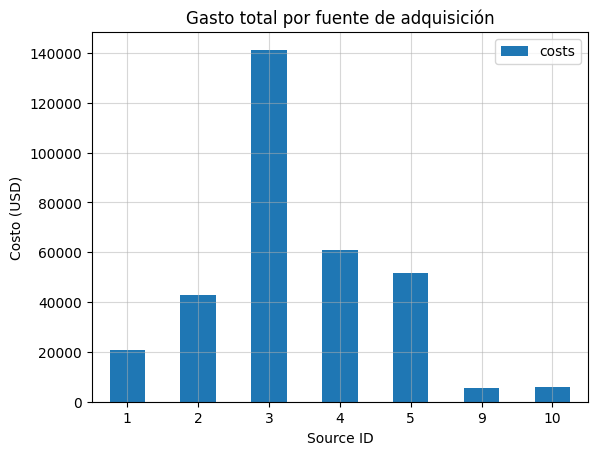

In [131]:
costs_x_source.plot(kind='bar',
                    x='source_id',
                    y='costs',
                    title="Gasto total por fuente de adquisición",
                    ylabel="Costo (USD)",
                    xlabel= 'Source ID',
                    rot=0)
plt.grid(alpha=0.5)


Gasto a lo largo del tiempo (mensual).

- Calculamos el gasto mensual total para observar cómo haevolucionado la inversión en marketing a lo largo del período analizado. 

In [132]:
monthly_cost = costs.groupby('month')['costs'].sum().reset_index()
monthly_cost


,month,costs
0,2017-06,18015.00
1,2017-07,18240.59
2,2017-08,14790.54
3,2017-09,24368.91
4,2017-10,36322.88
5,2017-11,37907.88
6,2017-12,38315.35
7,2018-01,33518.52
8,2018-02,32723.03
9,2018-03,30415.27


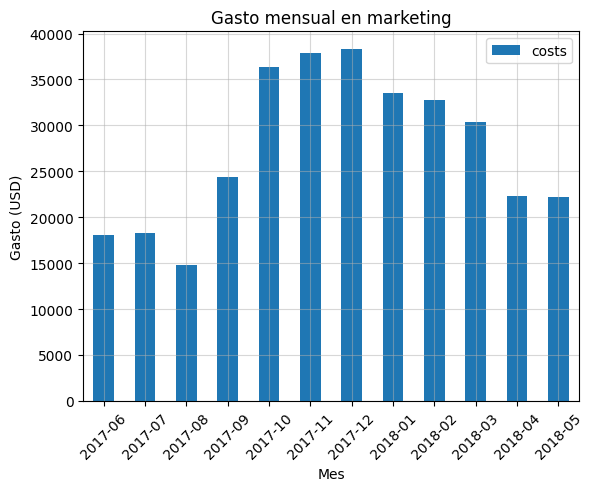

In [133]:
monthly_cost.plot(kind='bar',
                  ylabel="Gasto (USD)",
                  xlabel="Mes",
                  x="month",
                  y="costs",
                  title="Gasto mensual en marketing",
                  rot=45)
plt.grid(alpha=0.5)

### Gasto por mes y fuente

- Creamos una tabla pivot para ver el gasto mensual desglosado por fuente. Esto nos permite identificar si el presupuesto de cada fuente ha variado a lo largo del tiempo.

In [134]:
spend_month_source = costs.pivot_table(
    index='month',
    columns='source_id',
    values='costs',
    aggfunc='sum'
).fillna(0)

spend_month_source


source_id,1,2,3,4,5,9,10
month,,,,,,,
2017-06,1125.61,2427.38,7731.65,3514.80,2616.12,285.22,314.22
2017-07,1072.88,2333.11,7674.37,3529.73,2998.14,302.54,329.82
2017-08,951.81,1811.05,6143.54,3217.36,2185.28,248.93,232.57
2017-09,1502.01,2985.66,9963.55,5192.26,3849.14,415.62,460.67
2017-10,2315.75,4845.00,15737.24,6420.84,5767.40,609.41,627.24
2017-11,2445.16,5247.68,17025.34,5388.82,6325.34,683.18,792.36
2017-12,2341.20,4897.80,16219.52,7680.47,5872.52,657.98,645.86
2018-01,2186.18,4157.74,14808.78,5832.79,5371.52,547.16,614.35
2018-02,2204.48,4474.34,14228.56,5711.96,5071.31,551.50,480.88


### Gasto total

In [135]:
print("Gasto total:", monthly_cost['costs'].sum(), "USD")

Gasto total: 329131.62 USD


- Hubo un gasto total, de 329,132 USD.

- La fuente #3 concentra la mayor parte del presupuesto de marketing. 

2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
 

In [136]:
first_touch = (visits.sort_values('start_ts')
               .drop_duplicates('uid')[['uid','source_id']]
               .rename(columns={'source_id':'acq_source'}))
first_touch.reset_index()
first_buy_month = (orders.groupby('uid')['order_month'].min().rename('first_buy_month'))
first_buy_month = first_buy_month.reset_index()
buyers = first_buy_month.merge(first_touch, on='uid', how='left')
new_buyers_source_month = (buyers.groupby(['acq_source', 'first_buy_month'])['uid'].nunique().rename('new_buyers'))
new_buyers_source_month = new_buyers_source_month.reset_index()
new_buyers_source_month

,acq_source,first_buy_month,new_buyers
0,1,2017-06,190
1,1,2017-07,160
2,1,2017-08,113
3,1,2017-09,227
4,1,2017-10,340
...,...,...,...
81,10,2018-01,92
82,10,2018-02,123
83,10,2018-03,186
84,10,2018-04,107


- Calculamos el CAC dividiendo el gasto de cada fuente por mes entre el número de nuevos compradores que trajo esa fuente ese mes. Luego agregamos por fuente para obtener el CAC global de cada canal.

In [137]:
spend_source_month = (costs.groupby(['source_id','month'])['costs']
                      .sum()
                      .rename('spend')).reset_index()
spend_source_month

,source_id,month,spend
0,1,2017-06,1125.61
1,1,2017-07,1072.88
2,1,2017-08,951.81
3,1,2017-09,1502.01
4,1,2017-10,2315.75
...,...,...,...
79,10,2018-01,614.35
80,10,2018-02,480.88
81,10,2018-03,526.41
82,10,2018-04,388.25


In [138]:
cac_source_month = spend_source_month.merge(
    new_buyers_source_month,
    left_on=['source_id', 'month'],
    right_on=['acq_source', 'first_buy_month']
)
cac_source_month

,source_id,month,spend,acq_source,first_buy_month,new_buyers
0,1,2017-06,1125.61,1,2017-06,190
1,1,2017-07,1072.88,1,2017-07,160
2,1,2017-08,951.81,1,2017-08,113
3,1,2017-09,1502.01,1,2017-09,227
4,1,2017-10,2315.75,1,2017-10,340
...,...,...,...,...,...,...
79,10,2018-01,614.35,10,2018-01,92
80,10,2018-02,480.88,10,2018-02,123
81,10,2018-03,526.41,10,2018-03,186
82,10,2018-04,388.25,10,2018-04,107


In [139]:
cac_source_month['cac'] = cac_source_month['spend'] / cac_source_month['new_buyers']
cac_source_month = cac_source_month.replace([np.inf,-np.inf], np.nan).dropna()

cac_source_month

,source_id,month,spend,acq_source,first_buy_month,new_buyers,cac
0,1,2017-06,1125.61,1,2017-06,190,5.924263
1,1,2017-07,1072.88,1,2017-07,160,6.705500
2,1,2017-08,951.81,1,2017-08,113,8.423097
3,1,2017-09,1502.01,1,2017-09,227,6.616784
4,1,2017-10,2315.75,1,2017-10,340,6.811029
...,...,...,...,...,...,...,...
79,10,2018-01,614.35,10,2018-01,92,6.677717
80,10,2018-02,480.88,10,2018-02,123,3.909593
81,10,2018-03,526.41,10,2018-03,186,2.830161
82,10,2018-04,388.25,10,2018-04,107,3.628505


In [140]:
cac_by_source = (cac_source_month.groupby('source_id')
                 .apply(lambda df: df['spend'].sum() / df['new_buyers'].sum())
                 .sort_values().rename('cac')).reset_index()
cac_by_source

/var/folders/4r/_2_gyjpn18sb18dbg9jxs5ym0000gn/T/ipykernel_30317/3219426988.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df['spend'].sum() / df['new_buyers'].sum())


,source_id,cac
0,10,4.381106
1,9,5.071222
2,4,5.932356
3,1,7.186364
4,5,7.467479
5,2,12.209367
6,3,13.493901


Lo visualizamos.

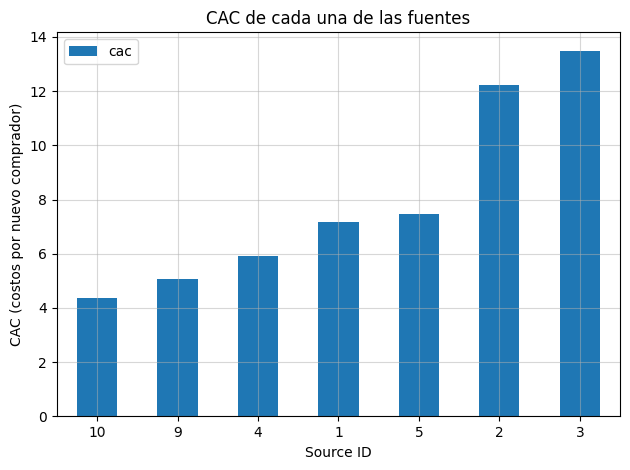

In [141]:
cac_by_source.plot(kind='bar',
                   y='cac',
                   x='source_id',
                   rot=1)
plt.title('CAC de cada una de las fuentes')
plt.xlabel("Source ID")
plt.ylabel('CAC (costos por nuevo comprador)')
plt.grid(alpha=0.5)
plt.tight_layout()


- Notamos que la fuente más eficiente fue la #10 de $4.38,   siguiendo la #9 de $5.07 y la #4 con $5.93 USD.

- La fuente #3 de $13.49 USD es el más alto, siendo además la que mas presupuesto consume.

Agregamos los datos sobre los costos al informe y calculamos el CAC

In [142]:
report = pd.merge(report, monthly_cost, left_on='first_order_month', right_on='month')
report['cac'] = report['costs'] / report['n_buyers']

report

,first_order_month,n_buyers,order_month,revenue,age,ltv,month,costs,cac
0,2017-06,2023,2017-06,9557.49,0,4.724414,2017-06,18015.00,8.905091
1,2017-06,2023,2017-07,981.82,1,0.485329,2017-06,18015.00,8.905091
2,2017-06,2023,2017-08,885.34,2,0.437637,2017-06,18015.00,8.905091
3,2017-06,2023,2017-09,1931.30,3,0.954671,2017-06,18015.00,8.905091
4,2017-06,2023,2017-10,2068.58,4,1.022531,2017-06,18015.00,8.905091
...,...,...,...,...,...,...,...,...,...
73,2018-03,3533,2018-04,1063.05,1,0.300892,2018-03,30415.27,8.608907
74,2018-03,3533,2018-05,1114.87,2,0.315559,2018-03,30415.27,8.608907
75,2018-04,2276,2018-04,10600.69,0,4.657597,2018-04,22289.38,9.793225
76,2018-04,2276,2018-05,1209.92,1,0.531599,2018-04,22289.38,9.793225


#### ROMI


- Para comenzar agregarmos el ROMI como columna al informe.

In [143]:
report['romi'] = report['ltv'] / report['cac']
report

,first_order_month,n_buyers,order_month,revenue,age,ltv,month,costs,cac,romi
0,2017-06,2023,2017-06,9557.49,0,4.724414,2017-06,18015.00,8.905091,0.530530
1,2017-06,2023,2017-07,981.82,1,0.485329,2017-06,18015.00,8.905091,0.054500
2,2017-06,2023,2017-08,885.34,2,0.437637,2017-06,18015.00,8.905091,0.049145
3,2017-06,2023,2017-09,1931.30,3,0.954671,2017-06,18015.00,8.905091,0.107205
4,2017-06,2023,2017-10,2068.58,4,1.022531,2017-06,18015.00,8.905091,0.114825
...,...,...,...,...,...,...,...,...,...,...
73,2018-03,3533,2018-04,1063.05,1,0.300892,2018-03,30415.27,8.608907,0.034951
74,2018-03,3533,2018-05,1114.87,2,0.315559,2018-03,30415.27,8.608907,0.036655
75,2018-04,2276,2018-04,10600.69,0,4.657597,2018-04,22289.38,9.793225,0.475594
76,2018-04,2276,2018-05,1209.92,1,0.531599,2018-04,22289.38,9.793225,0.054282


- Creamos una tabla pivote para que nos de el promedio de los valores del ROMI dependendo la cohorte.

In [144]:
output_romi = report.pivot_table(
    index='first_order_month',
    columns='age',
    values='romi',
    aggfunc='mean'
)
output_romi.cumsum(axis=1).round(2)


age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,0.53,0.59,0.63,0.74,0.86,0.94,1.05,1.11,1.17,1.24,1.31,1.33
2017-07,0.63,0.67,0.73,0.77,0.79,0.81,0.82,0.84,0.85,0.87,0.88,NaN
2017-08,0.49,0.53,0.57,0.61,0.66,0.68,0.70,0.74,0.77,0.78,NaN,NaN
2017-09,0.60,0.72,0.77,1.19,1.23,1.30,1.38,1.40,1.42,NaN,NaN,NaN
2017-10,0.60,0.66,0.68,0.70,0.72,0.74,0.75,0.76,NaN,NaN,NaN,NaN
2017-11,0.55,0.60,0.62,0.65,0.67,0.68,0.69,NaN,NaN,NaN,NaN,NaN
2017-12,0.54,0.57,0.68,0.80,0.84,0.87,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,0.42,0.45,0.48,0.49,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,0.46,0.49,0.50,0.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Calculamos el ROMI por fuente de adquisición: obtenemos el LTV promedio por fuente y lo dividimos entre el CAC correspondiente.

In [145]:
orders_source = orders.merge(first_touch, on='uid', how='left')

ltv_by_source = (orders_source.groupby('acq_source')['revenue'].sum() /
                 orders_source.groupby('acq_source')['uid'].nunique()).rename('ltv').reset_index()
ltv_by_source.columns = ['source_id', 'ltv']

romi_by_source = ltv_by_source.merge(cac_by_source, on='source_id')
romi_by_source['romi'] = romi_by_source['ltv'] / romi_by_source['cac']
romi_by_source = romi_by_source.sort_values('romi', ascending=False)

romi_by_source

,source_id,ltv,cac,romi
0,1,10.724577,7.186364,1.492351
1,2,13.383802,12.209367,1.096191
5,9,5.293566,5.071222,1.043844
4,5,7.592558,7.467479,1.016750
3,4,5.506685,5.932356,0.928246
6,10,3.348631,4.381106,0.764335
2,3,5.204931,13.493901,0.385725


Enseñamos ROMI por fuente

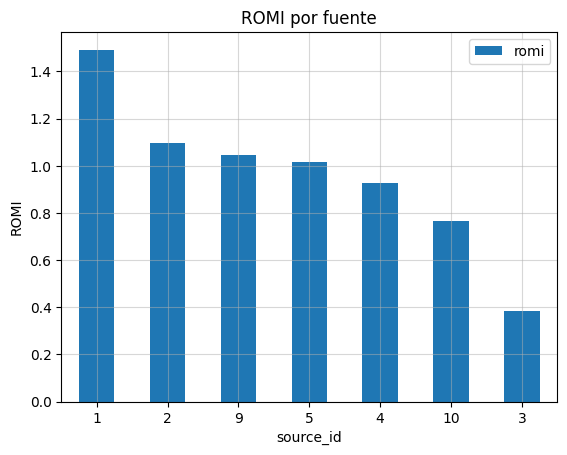

In [146]:
romi_by_source.plot(kind='bar',
                    x='source_id',
                    y='romi',
                    rot=0,
                    title='ROMI por fuente',
                    xlabel='source_id',
                    ylabel='ROMI')

plt.grid(alpha=0.5)


- Nuestro puento de quiebre es 1.0 todo arriba es rentable.

    Fuentes rentables: 
    1, 2, 9 y 5.

- Calculamos el LTV promedio por dispositivo para ver que usuarios generan más ingresos, si los de móvil o desktop.

In [147]:
visits_orders = orders.merge(
    visits[['uid', 'device']].drop_duplicates('uid'),
    on='uid', how='left'
)

ltv_by_device = (visits_orders.groupby('device')['revenue'].sum() /
                 visits_orders.groupby('device')['uid'].nunique()).rename('ltv').reset_index()

ltv_by_device


,device,ltv
0,desktop,7.238786
1,touch,5.550663


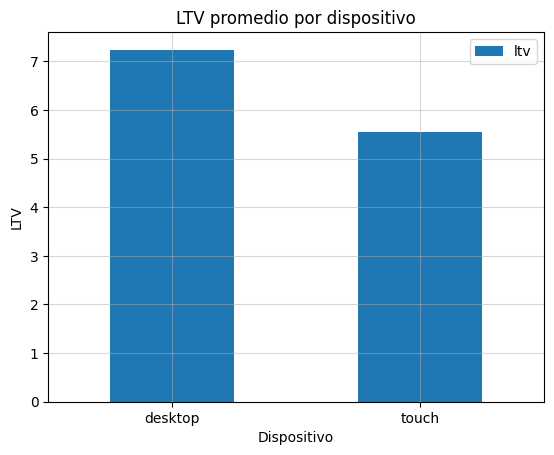

In [148]:
ltv_by_device.plot(kind='bar', 
                   x='device',
                   y='ltv',
                   rot=0,
                   title='LTV promedio por dispositivo',
                   xlabel='Dispositivo',
                    ylabel='LTV')
plt.grid(alpha=0.5)

- Los usuarios de desktop generan mayor LTV que los de dispositivos móviles.

- El proceso de compra en pantalla grande favorece mayor gasto por usuario.

- Observamos que las campañas orientadas a desktop podrían tener mayor retorno.

---

## 3. Hallazgos y recomendaciones de presupuesto de marketing.


Con base en el análisis de CAC, LTV y ROMI por fuente de adquisición, 
presentamos las recomendaciones para optimizar el presupuesto de marketing de Showz.


### ¿En qué métricas nos enfocamos y por qué?

- CAC (Costo de Adquisición de Cliente): nos dice cuánto cuesta conseguir un nuevo 
  comprador desde cada fu
ente. Un CAC bajo es deseable, pero solo tiene sentido si el 
  LTV lo supera — un CAC bajo con LTV aún más bajo sigue siendo un mal negocio.

- LTV (Lifetime Value): mide cuánto dinero genera en promedio cada cliente a lo largo 
  de su ciclo de vida. Es la contraparte del CAC — juntos determinan si una fuente es rentable.

- ROMI (Return On Marketing Investment): es la métrica integradora principal. 
  Se calcula como ROMI = LTV / CAC. Un ROMI > 1 significa que por cada peso invertido 
  se recupera más de uno en ingresos. Un ROMI < 1 significa pérdida neta.

Estas tres métricas juntas nos dan una visión completa de la rentabilidad de cada canal, 
no solo del costo o del ingreso por separado.


### Fuentes recomendadas para aumentar inversión

- La fuente 1 es la más recomendada con un ROMI de 1.49, CAC de $7.19 y LTV de $10.72 — se recomienda aumentar el presupuesto.

- La fuente 2 tiene un ROMI de 1.10, CAC de $12.21 y LTV de $13.38 — se recomienda mantener la inversión actual pero monitorear el CAC de cerca.

- La fuente 9 tiene un ROMI de 1.04, CAC de $5.07 y LTV de $5.29 — se recomienda mantener o incrementar moderadamente.

- La fuente 5 tiene un ROMI de 1.02, CAC de $7.47 y LTV de $7.59 — se recomienda mantener la inversión actual.

---

### Fuentes a reducir o eliminar

- La fuente 3 es el caso más crítico: ROMI de 0.39, CAC de $13.49, LTV de $5.20 y concentra el 43% del presupuesto total. Se recomienda reducir drásticamente o eliminar.

- La fuente 4 tiene un ROMI de 0.93, CAC de $5.93 y LTV de $5.51, representando el 19% del presupuesto. Al estar justo por debajo del break-even se recomienda optimizar antes de eliminar.

- La fuente 10 tiene un ROMI de 0.76, CAC de $4.38 y LTV de $3.35, con apenas el 2% del presupuesto. Se recomienda investigar la calidad del tráfico que genera antes de tomar una decisión.

---

### Hallazgos clave del análisis

- El 72.2% de los usuarios compra el mismo día de su primera visita. Esto indica 
   alta intención de compra desde el primer contacto. Las estrategias de remarketing 
   de largo plazo tienen poco impacto — es más efectivo invertir en capturar al usuario 
   en su primera visita con anuncios bien segmentados.

- El ticket promedio es de $5 USD, un valor relativamente bajo. Esto implica que 
   el volumen de clientes es fundamental para la rentabilidad — adquirir muchos clientes 
   a bajo costo es más importante que adquirir pocos clientes de alto valor.

- El 10% de las sesiones dura 0 segundos (rebotes inmediatos). Esto puede indicar 
   que ciertas fuentes traen tráfico de baja calidad que no interactúa con la plataforma. 
   Vale la pena cruzar este dato con la fuente de adquisición para identificar cuáles 
   generan más rebotes.

- La estacionalidad es clara: los picos de compras ocurren en noviembre y febrero-marzo. 
   Las campañas de marketing deberían intensificarse al menos 2-4 semanas antes de esos períodos 
   para maximizar el impacto.

- Los usuarios de desktop generan mayor LTV que los de dispositivos móviles. 
   Las campañas orientadas a usuarios de escritorio podrían tener mejor retorno por usuario adquirido.

---

### Conclusión general

- El área de marketing de Showz enfrenta un problema central: la concentración excesiva de presupuesto en la fuente 3, que no solo es la más costosa sino la menos rentable. 

- La recomendación principal es redirigir el presupuesto de la fuente 3 hacia las fuentes 1 y 9, 
que combinan buena rentabilidad con costos de adquisición razonables. Esta redistribución, 
sin aumentar el presupuesto total, podría mejorar significativamente el ROMI global del área.

- Adicionalmente, dado que la mayoría de los usuarios convierte en su primera visita, 
la prioridad debe ser atraer usuarios con alta intención de compra desde el primer 
contacto, en lugar de invertir en estrategias de retención o remarketing costosas.